<a href="https://colab.research.google.com/github/profsuccodifrutta/Variational_Autoencoder_for_Anomaly_Detection/blob/main/VAE_V6_lightt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Overview: Brain Tumor Detection using Variational Autoencoders (VAE)**



OBJECTIVE: The primary goal of this project is to develop an unsupervised learning
framework for the identification of brain tumors in MRI scans. By leveraging the principles of anomaly detection, the system aims to distinguish between healthy brain tissue and pathological structures without requiring extensive labeled datasets of various tumor types.

METHODOLOGY: Variational Autoencoders are generative models trained exclusively on images of healthy brain scans. The VAE learns to compress these images into a lower-dimensional latent space and then reconstruct them.



1.   Encoding: The model learns a distribution of features representing "normal" brain anatomy.

2.   Decoding: The model attempts to reconstruct the original image from this latent distribution.

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/dataset_local
path_zip = "/content/drive/MyDrive/brainmri.zip"
!unzip -o -q "{path_zip}" -d /content/dataset_local

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import glob
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score)
import random

**Dataset Description**

For this project, has beed used the Brain Tumor MRI Dataset sourced from Kaggle. While this dataset is originally designed for multi-class classification (categorizing tumors into Glioma, Meningioma, Pituitary, or No Tumor), it can also be adapted  for unsupervised anomaly detection.

A custom BrainDataset class facilitates efficient data handling within the PyTorch framework. This class manages the loading of files and ensures consistency by converting images to grayscale ('L').

In [ ]:
class BrainDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image

The data pipeline involves splitting strategy to ensure model generalizability. Healthy images are partitioned using a 70/20/10 split, while all tumorous images are reserved strictly for the final testing phase.

* Training and Validation: Composed exclusively using images labeled as notumor (healthy scans).

*   Testing: The test set is composed of both healthy and non healthy images.

A fixed seed (42) is utilized during the random_split process to maintain reproducibility across different training runs.

In [ ]:
file_sani = glob.glob("/content/dataset_local/**/Training/notumor/*.jpg", recursive=True)
print(f"Total healthy images: {len(file_sani)}")


full_healthy_ds = BrainDataset(file_sani)

train_size = int(0.7 * len(full_healthy_ds))
val_size = int(0.2 * len(full_healthy_ds))
test_size = len(full_healthy_ds) - train_size - val_size

train_subset, val_subset, test_healthy_subset = random_split(
    full_healthy_ds, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

file_anomalie = glob.glob("/content/dataset_local/**/Testing/*/*.jpg", recursive=True)
file_anomalie = [f for f in file_anomalie if "notumor" not in f]


test_anomaly_ds = BrainDataset(file_anomalie)

print(f"Training: {len(train_subset)} | Val: {len(val_subset)} | Test : {len(test_healthy_subset)}")
print(f"Anomalies for test: {len(file_anomalie)}")

Total healthy images: 1595
Training: 1116 | Val: 319 | Test : 160
Anomalies for test: 906


**Data Preprocessing and Augmentation**

All images are resized to 224x224 pixels. This ensures consistent input dimensions. Additionaly is applied a RandomHorizontalFlip with a probability of $p=0.5$. This technique artificially increases the dataset's diversity, helping the model become invariant to horizontal orientation and reducing the risk of overfitting. The ToTensor() operation scales the pixel intensity values from the range [0, 255] to a floating-point range of [0, 1].

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

**Batch Configuration and Data Loading**

The data is managed through PyTorch DataLoaders to optimize memory usage and computational efficiency. The train_loader uses shuffle=True. Shuffling at each epoch is critical to ensure the model does not learn the order of the training samples, promoting better generalization.

In [ ]:
batch_size = 32

train_loader = DataLoader(
    BrainDataset([train_subset.dataset.file_list[i] for i in train_subset.indices], transform=train_transform),
    batch_size=batch_size, shuffle=True)

val_loader = DataLoader(
    BrainDataset([val_subset.dataset.file_list[i] for i in val_subset.indices], transform=base_transform),
    batch_size=batch_size, shuffle=False)

**Residual Block**

By utilizing the identity mapping principle introduced by He et al. (2016), the block allows the network to learn residual functions rather than direct mappings, which significantly eases the optimization process. The skip connection ($x + \text{conv}(x)$) ensures that the gradient can bypass the non-linear transformations, mitigating the vanishing gradient problem. This is crucial for ensuring that the initial layers of the encoder still receive strong signals during backpropagation.

The choice of LeakyReLU ($0.2$) is strategically superior to standard ReLU in this context. Radford et al. (2015) demonstrated in their work on DCGANs ("Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks") that LeakyReLU is superior for learning stable filters in the encoder sections of generative architectures. Additionally allowing a small negative slope prevents the "dying ReLU" problem.



In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels)
        )
        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.relu(x + self.conv(x))

**Architecture**

The VAE architecture is designed as a symmetric bottleneck model. The Encoder utilizes a series of strided convolutions and Residual Blocks to compress the $224 \times 224$ input into a high-level feature map, which is then projected into a 2048-dimensional latent space. To ensure the network remains differentiable, the model implements the reparameterization trick: instead of sampling directly from the stochastic distribution, it computes a latent vector $z = \mu + \epsilon \odot \sigma$, where $\epsilon \sim \mathcal{N}(0, 1)$. This formulation allows the gradients to bypass the sampling process during backpropagation. The Decoder subsequently mirrors the encoder’s structure, using transposed convolutions to reconstruct the original image. By training exclusively on healthy samples, the model learns a constrained manifold of normal brain anatomy; consequently, any structural anomaly in the test data results in a high reconstruction error, which serves as a primary metric for anomaly detection.

In the encoder, the images pass through nine convolutional layers, including those within the Residual Blocks, to extract hierarchical features. Once the final feature map is reached, a flattening operation is applied, resulting in 12,544 neurons which are fully connected to a 4,096-neuron hidden layer. This representation is finally reduced to 2,048 latent dimensions. This intermediate layer was added to provide gradual dimensionality reduction, ensuring that complex spatial information is distilled effectively without significant data loss before reaching the stochastic bottleneck.

In [ ]:
import torch
import torch.nn as nn



class VAE_V6_Light(nn.Module):

    def __init__(self, latent_dim=512):
        super(VAE_V6_Light, self).__init__()

        # ENCODER: 224 -> 112 -> 56 -> 28 -> 14 -> 7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            ResBlock(64),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            ResBlock(128),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2)
        )

        self.flatten_dim = 256 * 7 * 7


        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, self.flatten_dim),
            nn.LeakyReLU(0.2)
        )

        self.unflatten = nn.Unflatten(1, (256, 7, 7))

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 256, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            ResBlock(128),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            ResBlock(64),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            if m.out_channels == 1:
                nn.init.xavier_normal_(m.weight)
            else:
                nn.init.kaiming_normal_(m.weight, a=0.2, mode='fan_out', nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        h = torch.flatten(h, start_dim=1)


        mu, logvar = self.fc_mu(h), self.fc_logvar(h)


        logvar = torch.clamp(logvar, -10, 10)

        z = self.reparameterize(mu, logvar)
        dec_hid = self.decoder_input(z)
        x_recon = self.decoder(self.unflatten(dec_hid))
        return x_recon, mu, logvar

**Loss Function**

To optimize the training of the VAE, a composite loss function was implemented, combining pixel-wise accuracy, structural fidelity, and latent space regularization. The total loss is defined as:$$\mathcal{L}_{Total} = \mathcal{L}_{MaskedBCE} + 5 \cdot \mathcal{L}_{SSIM} + \beta \cdot \mathcal{L}_{KLD}$$


Masked Binary Cross-Entropy ($\mathcal{L}_{MaskedBCE}$): To prevent the model from overfitting to the uninformative black background of the brain scans, a intensity-based mask ($x > 0.05$) was applied. This ensures the reconstruction loss focuses exclusively on the anatomical structures.


Structural Similarity Index ($\mathcal{L}_{SSIM}$): SSIM evaluates the preservation of luminance, contrast, and structure. In medical imaging, maintaining structural integrity is vital, the SSIM component compels the model to reconstruct sharp edges and consistent tissue textures, which are often blurred by standard MSE or BCE losses.
The ssim_loss function is derived from the SSIM index, which compares two images ($x$ and $y$) based on three distinct components: luminance ($l$), contrast ($c$), and structure ($s$). Mathematically, the index is calculated within a local window (in this case, an $11 \times 11$ area) using the formula:

$$SSIM(x, y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}$$

Where: $\mu_x, \mu_y$ are the local means (luminance), $\sigma_x^2, \sigma_y^2$ are the local variances (contrast), $\sigma_{xy}$ is the local covariance (structural correlation), $C_1, C_2$ are constants ($0.01^2$ and $0.03^2$) to stabilize the division when the denominator is close to zero.
Since the goal is to minimize the difference between images, the loss is defined as $\mathcal{L}_{SSIM} = 1 - SSIM$. This forces the VAE to reconstruct not just the correct pixel intensities, but the specific spatial patterns and textures of the brain tissue.
The total loss utilizes a multiplier of 5 for the SSIM component. This coefficient was determined through manual tuning to achieve a magnitude balance between the Masked BCE and SSIM losses.

During training, pixel-wise losses (BCE) often yield different numerical scales than structural losses (SSIM). Without this scaling factor, the optimizer might prioritize intensity matching while neglecting structural sharpness, or vice versa. By applying the weight, both terms contribute with similar "intensity" to the total gradient, ensuring the model simultaneously learns global anatomical brightness and fine-grained structural detail.

Kullback-Leibler Divergence ($\mathcal{L}_{KLD}$): This term regularizes the latent space, forcing the encoded distributions to approximate a standard normal distribution $\mathcal{N}(0, I)$. To avoid the common issue of posterior collapse—where the KL divergence drops to zero and the model ignores the latent variables—a linear warmup (or annealing) strategy is implemented for the $\beta$ coefficient. The value of $\beta$ at any given epoch $t$ is defined by:$$\beta(t) = \min\left(\beta_{target}, \beta_{target} \cdot \frac{t}{T_{warmup}}\right)$$

In [ ]:
import torch
import torch.nn.functional as F

def ssim_loss(img1, img2, window_size=11):
    mu1 = F.avg_pool2d(img1, window_size, stride=1, padding=window_size//2)
    mu2 = F.avg_pool2d(img2, window_size, stride=1, padding=window_size//2)

    sigma1_sq = F.avg_pool2d(img1 * img1, window_size, stride=1, padding=window_size//2) - mu1.pow(2)
    sigma2_sq = F.avg_pool2d(img2 * img2, window_size, stride=1, padding=window_size//2) - mu2.pow(2)

    sigma1_sq = torch.clamp(sigma1_sq, min=0)
    sigma2_sq = torch.clamp(sigma2_sq, min=0)

    sigma12 = F.avg_pool2d(img1 * img2, window_size, stride=1, padding=window_size//2) - (mu1 * mu2)

    c1, c2 = 0.01**2, 0.03**2

    num = (2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)
    den = (mu1.pow(2) + mu2.pow(2) + c1) * (sigma1_sq + sigma2_sq + c2)

    return 1 - (num / (den + 1e-7)).mean()

def loss_function(recon_x, x, mu, logvar, beta=0.005):
    mask = (x > 0.05).float()

    recon_x = torch.clamp(recon_x, min=1e-7, max=1-1e-7)
    l1_per_pixel = F.l1_loss(recon_x, x, reduction='none')

    masked_l1 = (l1_per_pixel * mask).sum() / (mask.sum() + 1e-8)

    ssim = ssim_loss(recon_x, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = masked_l1 + (5 * ssim) + (beta * kl)

    return total_loss, masked_l1, kl

**Optimizer and Learning rate**

While the standard Adam optimizer is a common choice, AdamW (Adam with Decoupled Weight Decay) was selected for its superior handling of regularization. In traditional Adam, $L_2$ regularization is blended with the gradient updates. In AdamW, the weight decay is applied directly to the weights, separated from the adaptive gradient calculation. This leads to better generalization, which is critical in medical imaging.
The choice of the AdamW optimizer is further supported by recent theoretical analyses (e.g., Zhou et al. (2024)) which prove that decoupled weight decay provides superior convergence and generalization compared to standard $\ell_2$-regularized Adam. This is particularly relevant for over-parametrized networks like the VAE, where the dense bottleneck layer contains over 51 million parameters.

The ReduceLROnPlateau scheduler monitors the Validation Loss. If the loss ceases to improve for a set number of epochs (patience=5), the scheduler automatically reduces the learning rate by a factor of 0.5.

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 512
model = VAE_V6_Light(latent_dim=latent_dim).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


The plot_reconstruction function serves as a qualitative monitoring tool during training. By plotting the original brain scan alongside its reconstruction every 5 epochs, we can observe the progression of the model's learning.

In [ ]:
def plot_reconstruction(model, val_loader, device, epoch):
    model.eval()
    with torch.no_grad():
        # batch dal loader di validazione
        inputs = next(iter(val_loader))
        inputs = inputs.to(device)

        # Ricostruzione
        recons, mu, logvar = model(inputs)

        # su cpu per plottare
        img = inputs[0].cpu().squeeze().numpy()
        recon = recons[0].cpu().squeeze().numpy()

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img, cmap='gray')
        plt.title("Originale")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(recon, cmap='gray')
        plt.title(f"Ricostruzione Epoca {epoch+1}")
        plt.axis('off')

        plt.show()

In [ ]:
import numpy as np

# training loop

def train_vae(model, train_loader, val_loader, optimizer, scheduler, num_epochs):
    train_history = {'total': [], 'recon': [], 'kl': []}
    val_history = {'total': [], 'recon': [], 'kl': []}

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()

        current_beta = min(target_beta, target_beta * (epoch / warmup_epochs))

        train_total, train_recon, train_kl = 0, 0, 0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()
            recon_batch, mu, logvar = model(batch)

            loss, r_loss, k_loss = loss_function(recon_batch, batch, mu, logvar, beta=current_beta)

            if torch.isnan(loss):
                print(f" Batch saltato all'epoca {epoch+1}: rilevato NaN nella loss")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_total += loss.item()
            train_recon += r_loss.item()
            train_kl += k_loss.item()

        # VALIDATION
        model.eval()
        val_total, val_recon, val_kl = 0, 0, 0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                recon_batch, mu, logvar = model(batch)
                loss, r_loss, k_loss = loss_function(recon_batch, batch, mu, logvar, beta=current_beta)

                val_total += loss.item()
                val_recon += r_loss.item()
                val_kl += k_loss.item()


        avg_train_loss = train_total / len(train_loader)
        avg_val_loss = val_total / len(val_loader)

        scheduler.step(avg_val_loss)

        train_history['total'].append(avg_train_loss)
        val_history['total'].append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Beta: {current_beta:.5f} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), '/content/drive/MyDrive/VAE_Brain_Project/best_model_v6_light.pth')
            print(" Best model saved")


        if (epoch + 1) % 5 == 0:
            print(f"\n--- Reconstruction (Epoca {epoch+1}) ---")
            plot_reconstruction(model, val_loader, device, epoch)

            plt.figure(figsize=(8, 4))
            plt.plot(train_history['total'], label='Train Loss')
            plt.plot(val_history['total'], label='Val Loss')
            plt.title(f"Loss at epoch {epoch+1}")
            plt.legend()
            plt.show()

    return train_history, val_history

**Gradient Clipping**


The implementation of gradient clipping via torch.nn.utils.clip_grad_norm_ serves as a critical stabilization mechanism for the VAE training. Given the high capacity of the 51-million-parameter bottleneck and the sensitivity of the latent space's exponential terms ($e^{logvar}$), the model is susceptible to the exploding gradient problem. By capping the global $L_2$ norm of the gradients at 1.0, we ensure that the optimization steps remain within a stable range. This prevents numerical instability.

Epoch [1/80] | Beta: 0.00000 | Train Loss: 4.7439 | Val Loss: 4.6304
 Best model saved
Epoch [2/80] | Beta: 0.00025 | Train Loss: 4.6408 | Val Loss: 4.6114
 Best model saved
Epoch [3/80] | Beta: 0.00050 | Train Loss: 4.5998 | Val Loss: 4.5794
 Best model saved
Epoch [4/80] | Beta: 0.00075 | Train Loss: 4.5561 | Val Loss: 4.5126
 Best model saved
Epoch [5/80] | Beta: 0.00100 | Train Loss: 4.4485 | Val Loss: 4.3256
 Best model saved

--- Reconstruction (Epoca 5) ---


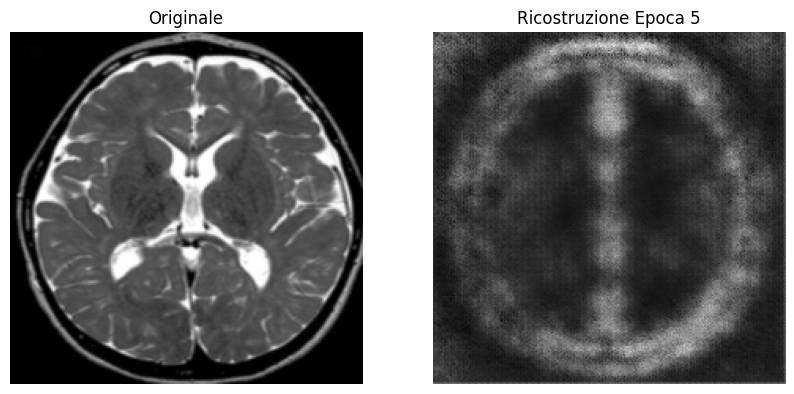

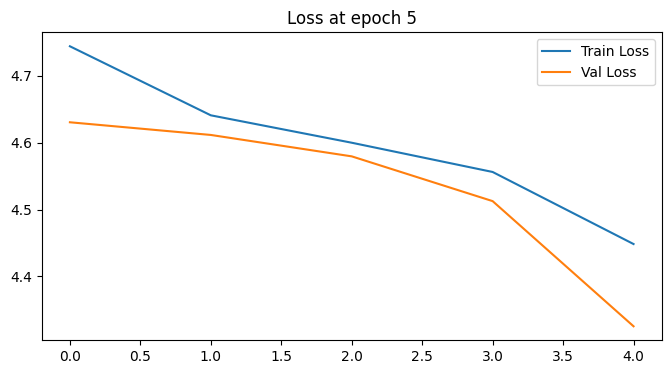

Epoch [6/80] | Beta: 0.00125 | Train Loss: 4.1342 | Val Loss: 3.9789
 Best model saved
Epoch [7/80] | Beta: 0.00150 | Train Loss: 3.7470 | Val Loss: 3.5941
 Best model saved
Epoch [8/80] | Beta: 0.00175 | Train Loss: 3.3907 | Val Loss: 3.3487
 Best model saved
Epoch [9/80] | Beta: 0.00200 | Train Loss: 3.1422 | Val Loss: 3.0419
 Best model saved
Epoch [10/80] | Beta: 0.00225 | Train Loss: 2.9548 | Val Loss: 2.9489
 Best model saved

--- Reconstruction (Epoca 10) ---


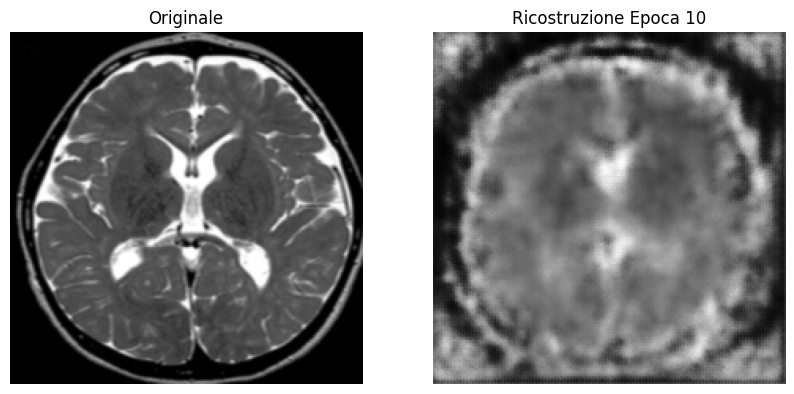

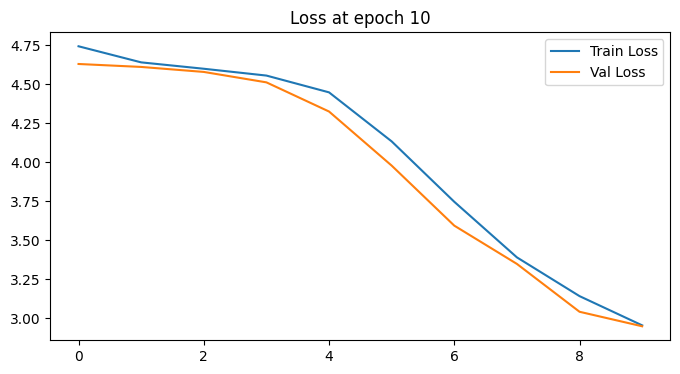

Epoch [11/80] | Beta: 0.00250 | Train Loss: 2.7936 | Val Loss: 2.8030
 Best model saved
Epoch [12/80] | Beta: 0.00275 | Train Loss: 2.6855 | Val Loss: 2.7323
 Best model saved
Epoch [13/80] | Beta: 0.00300 | Train Loss: 2.5723 | Val Loss: 2.6222
 Best model saved
Epoch [14/80] | Beta: 0.00325 | Train Loss: 2.4840 | Val Loss: 2.5486
 Best model saved
Epoch [15/80] | Beta: 0.00350 | Train Loss: 2.4164 | Val Loss: 2.5085
 Best model saved

--- Reconstruction (Epoca 15) ---


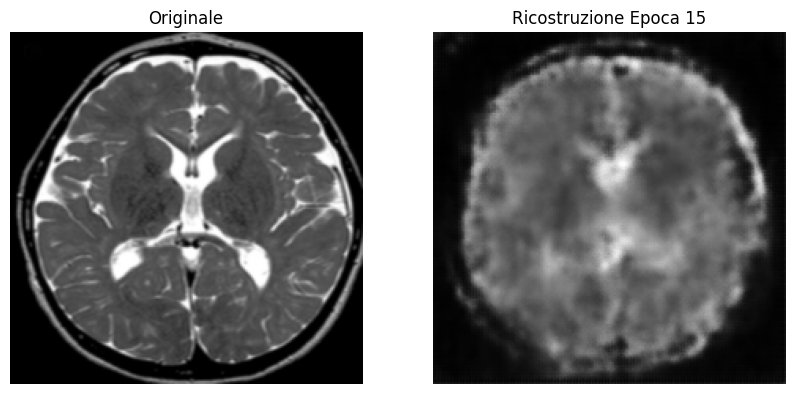

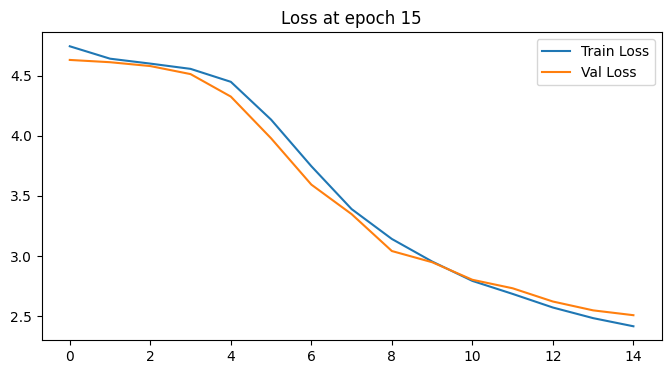

Epoch [16/80] | Beta: 0.00375 | Train Loss: 2.3403 | Val Loss: 2.4603
 Best model saved
Epoch [17/80] | Beta: 0.00400 | Train Loss: 2.2762 | Val Loss: 2.4174
 Best model saved
Epoch [18/80] | Beta: 0.00425 | Train Loss: 2.2117 | Val Loss: 2.4560
Epoch [19/80] | Beta: 0.00450 | Train Loss: 2.1520 | Val Loss: 2.3015
 Best model saved
Epoch [20/80] | Beta: 0.00475 | Train Loss: 2.1080 | Val Loss: 2.2838
 Best model saved

--- Reconstruction (Epoca 20) ---


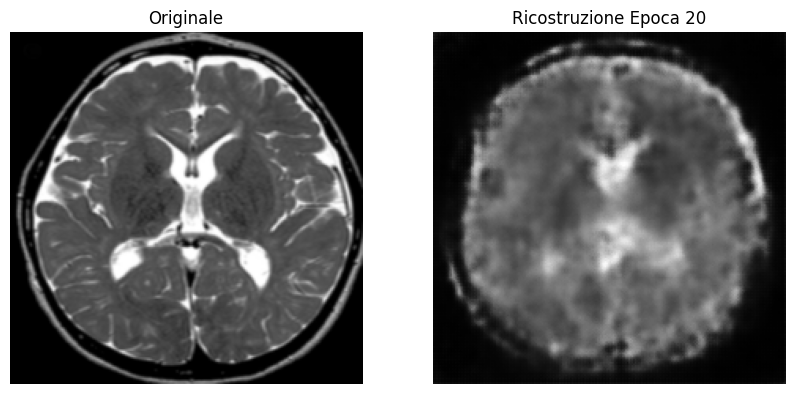

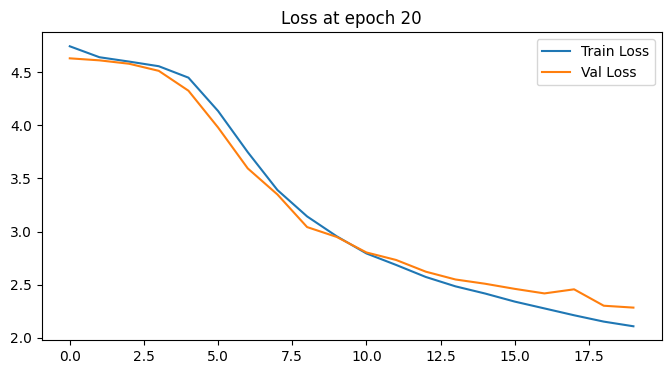

Epoch [21/80] | Beta: 0.00500 | Train Loss: 2.0525 | Val Loss: 2.2245
 Best model saved
Epoch [22/80] | Beta: 0.00500 | Train Loss: 2.0021 | Val Loss: 2.2115
 Best model saved
Epoch [23/80] | Beta: 0.00500 | Train Loss: 1.9702 | Val Loss: 2.1170
 Best model saved
Epoch [24/80] | Beta: 0.00500 | Train Loss: 1.9291 | Val Loss: 2.0892
 Best model saved
Epoch [25/80] | Beta: 0.00500 | Train Loss: 1.8903 | Val Loss: 2.0526
 Best model saved

--- Reconstruction (Epoca 25) ---


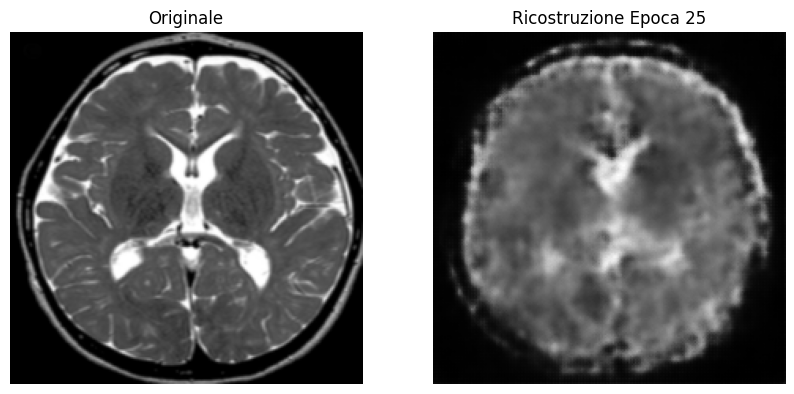

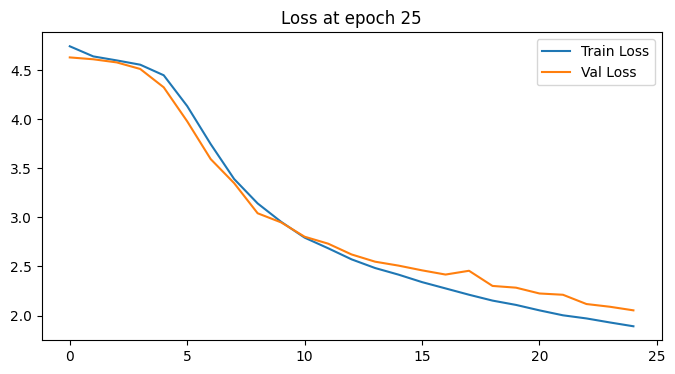

Epoch [26/80] | Beta: 0.00500 | Train Loss: 1.8481 | Val Loss: 2.0375
 Best model saved
Epoch [27/80] | Beta: 0.00500 | Train Loss: 1.8314 | Val Loss: 1.9946
 Best model saved
Epoch [28/80] | Beta: 0.00500 | Train Loss: 1.7816 | Val Loss: 2.0136
Epoch [29/80] | Beta: 0.00500 | Train Loss: 1.7444 | Val Loss: 1.9466
 Best model saved
Epoch [30/80] | Beta: 0.00500 | Train Loss: 1.7196 | Val Loss: 1.9376
 Best model saved

--- Reconstruction (Epoca 30) ---


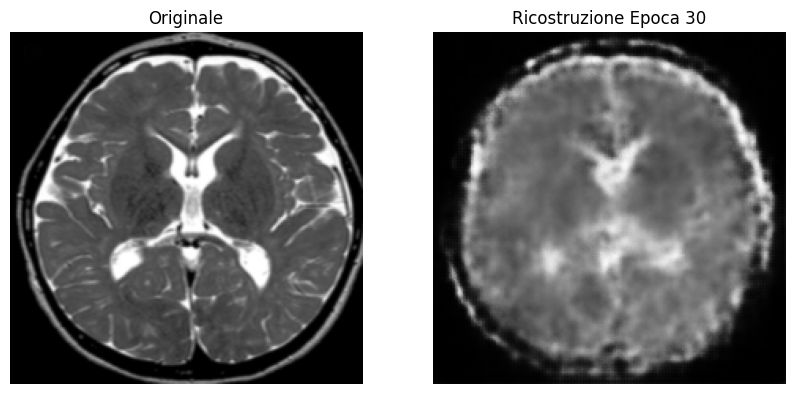

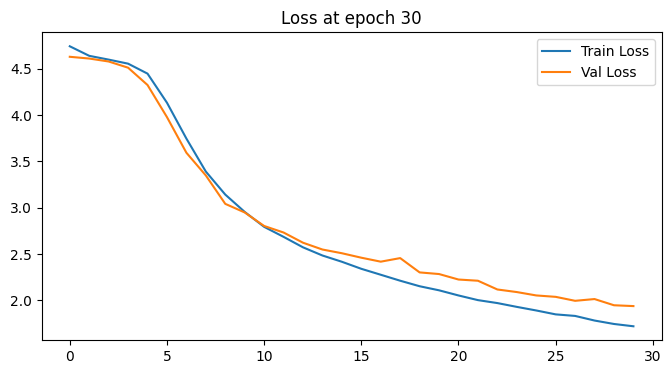

Epoch [31/80] | Beta: 0.00500 | Train Loss: 1.6814 | Val Loss: 1.8747
 Best model saved
Epoch [32/80] | Beta: 0.00500 | Train Loss: 1.6713 | Val Loss: 1.8717
 Best model saved
Epoch [33/80] | Beta: 0.00500 | Train Loss: 1.6286 | Val Loss: 1.8590
 Best model saved
Epoch [34/80] | Beta: 0.00500 | Train Loss: 1.6001 | Val Loss: 1.7962
 Best model saved
Epoch [35/80] | Beta: 0.00500 | Train Loss: 1.5676 | Val Loss: 1.7799
 Best model saved

--- Reconstruction (Epoca 35) ---


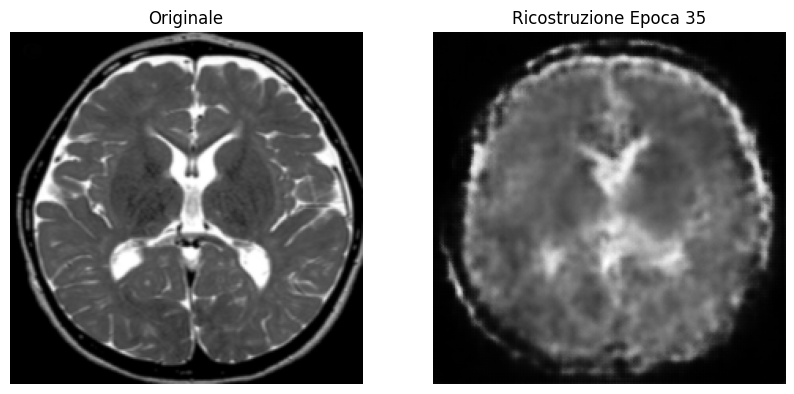

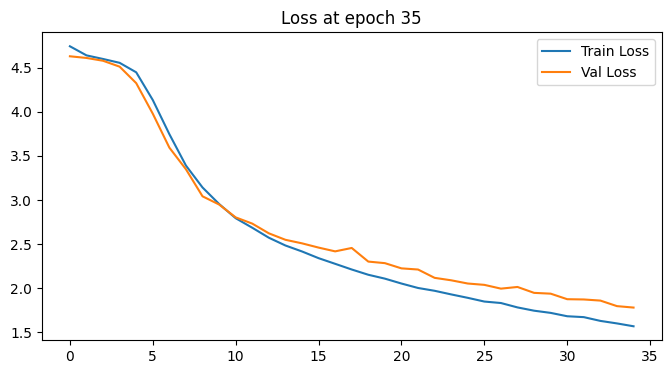

Epoch [36/80] | Beta: 0.00500 | Train Loss: 1.5665 | Val Loss: 1.7609
 Best model saved
Epoch [37/80] | Beta: 0.00500 | Train Loss: 1.5195 | Val Loss: 1.7357
 Best model saved
Epoch [38/80] | Beta: 0.00500 | Train Loss: 1.5188 | Val Loss: 1.7197
 Best model saved
Epoch [39/80] | Beta: 0.00500 | Train Loss: 1.4831 | Val Loss: 1.7343
Epoch [40/80] | Beta: 0.00500 | Train Loss: 1.4619 | Val Loss: 1.7484

--- Reconstruction (Epoca 40) ---


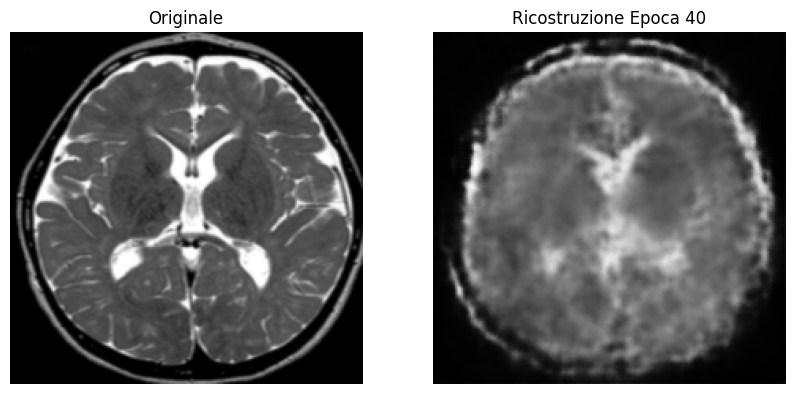

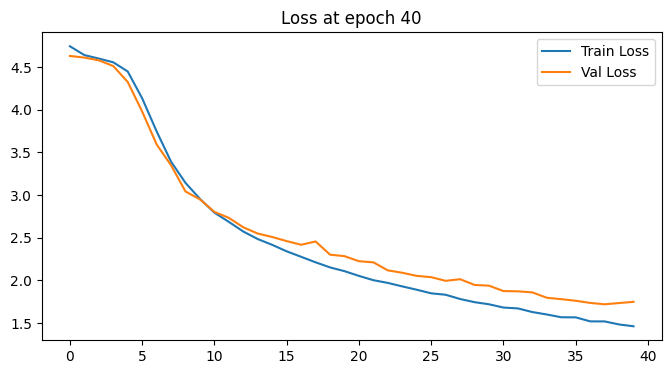

Epoch [41/80] | Beta: 0.00500 | Train Loss: 1.4423 | Val Loss: 1.6930
 Best model saved
Epoch [42/80] | Beta: 0.00500 | Train Loss: 1.4194 | Val Loss: 1.6478
 Best model saved
Epoch [43/80] | Beta: 0.00500 | Train Loss: 1.4194 | Val Loss: 1.6512
Epoch [44/80] | Beta: 0.00500 | Train Loss: 1.3990 | Val Loss: 1.6342
 Best model saved
Epoch [45/80] | Beta: 0.00500 | Train Loss: 1.3799 | Val Loss: 1.6390

--- Reconstruction (Epoca 45) ---


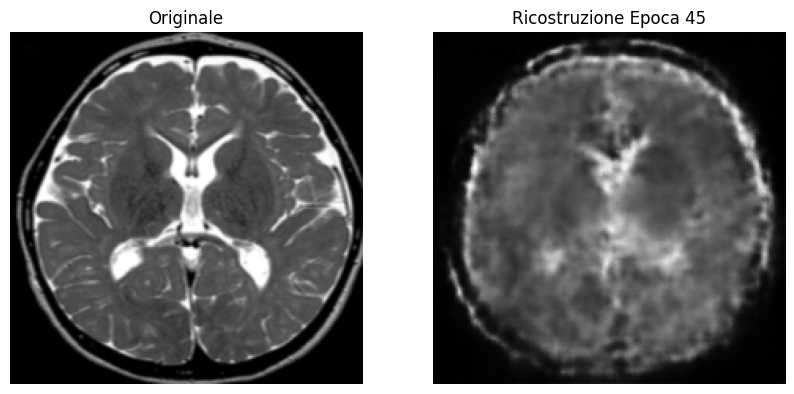

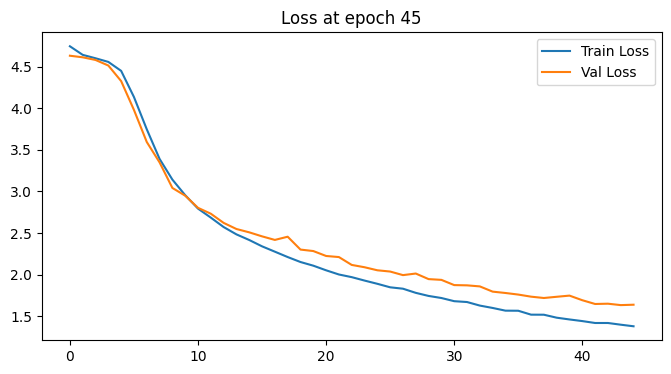

Epoch [46/80] | Beta: 0.00500 | Train Loss: 1.3738 | Val Loss: 1.6134
 Best model saved
Epoch [47/80] | Beta: 0.00500 | Train Loss: 1.3573 | Val Loss: 1.6158
Epoch [48/80] | Beta: 0.00500 | Train Loss: 1.3589 | Val Loss: 1.5936
 Best model saved
Epoch [49/80] | Beta: 0.00500 | Train Loss: 1.3364 | Val Loss: 1.5892
 Best model saved
Epoch [50/80] | Beta: 0.00500 | Train Loss: 1.3336 | Val Loss: 1.5835
 Best model saved

--- Reconstruction (Epoca 50) ---


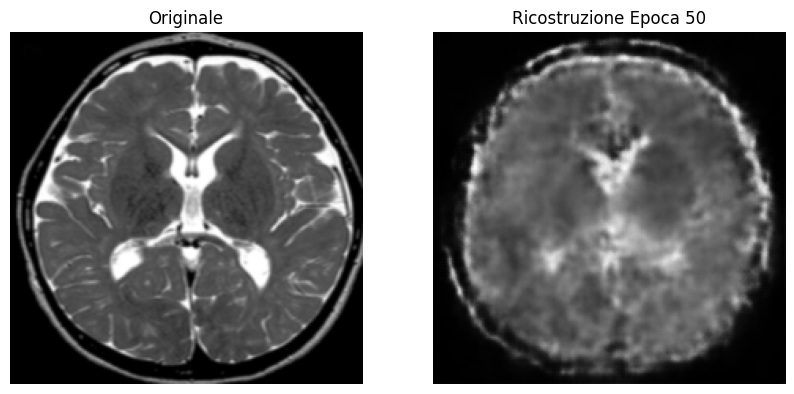

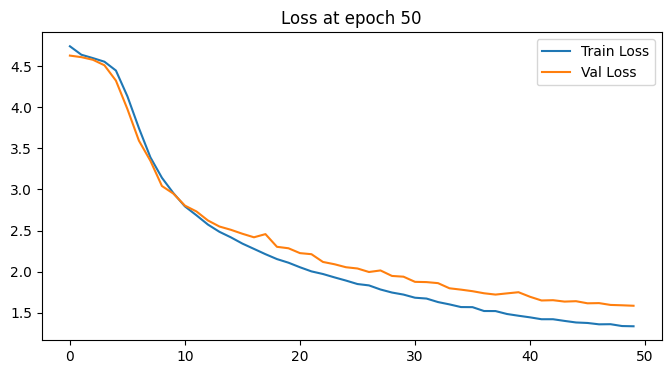

Epoch [51/80] | Beta: 0.00500 | Train Loss: 1.3176 | Val Loss: 1.5892
Epoch [52/80] | Beta: 0.00500 | Train Loss: 1.3059 | Val Loss: 1.6072
Epoch [53/80] | Beta: 0.00500 | Train Loss: 1.3033 | Val Loss: 1.5457
 Best model saved
Epoch [54/80] | Beta: 0.00500 | Train Loss: 1.2856 | Val Loss: 1.5465
Epoch [55/80] | Beta: 0.00500 | Train Loss: 1.2712 | Val Loss: 1.5675

--- Reconstruction (Epoca 55) ---


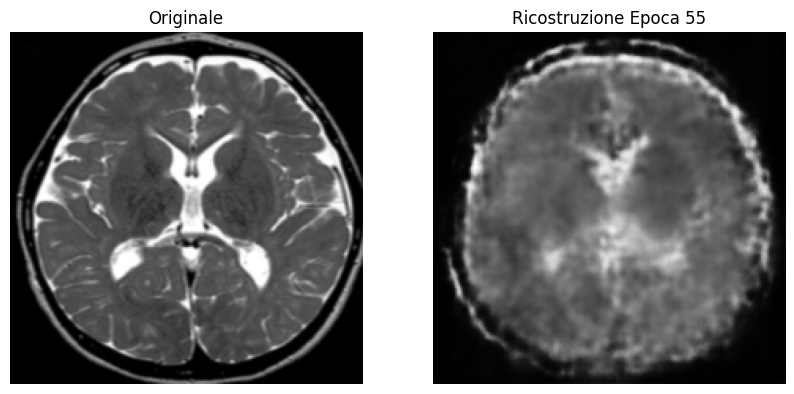

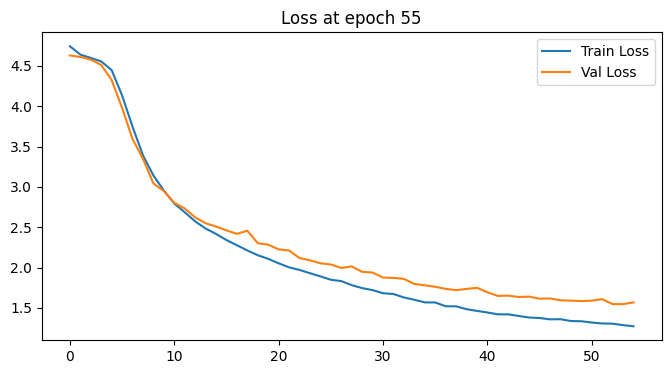

Epoch [56/80] | Beta: 0.00500 | Train Loss: 1.2748 | Val Loss: 1.5454
 Best model saved
Epoch [57/80] | Beta: 0.00500 | Train Loss: 1.2554 | Val Loss: 1.5225
 Best model saved
Epoch [58/80] | Beta: 0.00500 | Train Loss: 1.2581 | Val Loss: 1.5182
 Best model saved
Epoch [59/80] | Beta: 0.00500 | Train Loss: 1.2535 | Val Loss: 1.5091
 Best model saved
Epoch [60/80] | Beta: 0.00500 | Train Loss: 1.2393 | Val Loss: 1.5136

--- Reconstruction (Epoca 60) ---


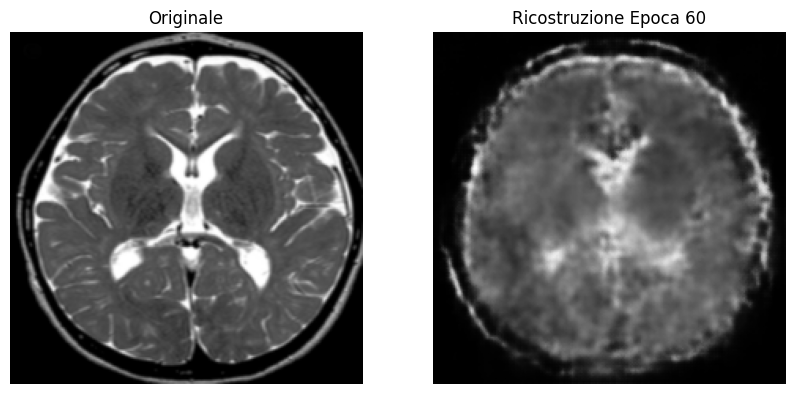

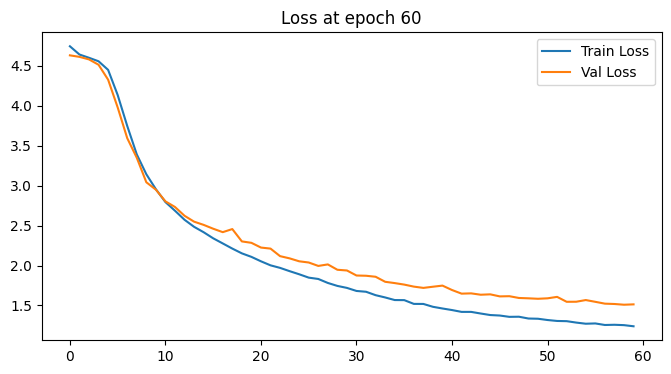

Epoch [61/80] | Beta: 0.00500 | Train Loss: 1.2353 | Val Loss: 1.5186
Epoch [62/80] | Beta: 0.00500 | Train Loss: 1.2361 | Val Loss: 1.5307
Epoch [63/80] | Beta: 0.00500 | Train Loss: 1.2266 | Val Loss: 1.4914
 Best model saved
Epoch [64/80] | Beta: 0.00500 | Train Loss: 1.2132 | Val Loss: 1.4997
Epoch [65/80] | Beta: 0.00500 | Train Loss: 1.2164 | Val Loss: 1.4851
 Best model saved

--- Reconstruction (Epoca 65) ---


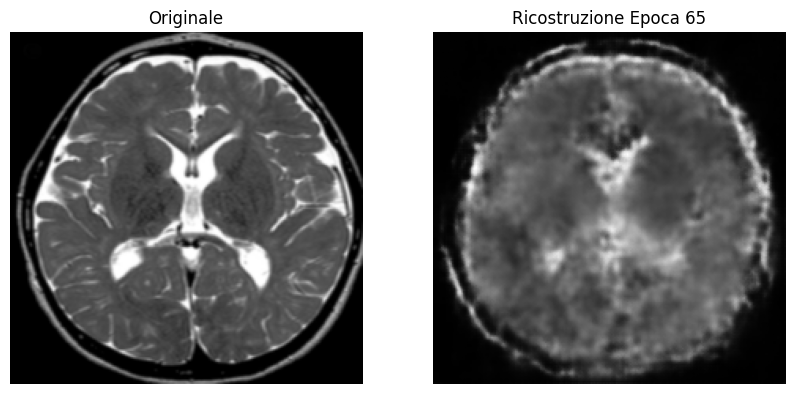

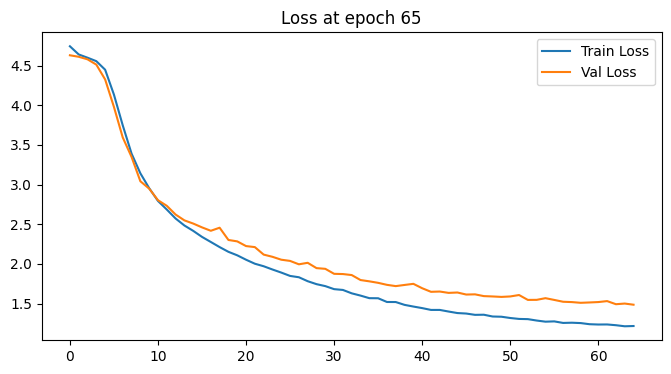

Epoch [66/80] | Beta: 0.00500 | Train Loss: 1.2146 | Val Loss: 1.5055
Epoch [67/80] | Beta: 0.00500 | Train Loss: 1.2114 | Val Loss: 1.5021
Epoch [68/80] | Beta: 0.00500 | Train Loss: 1.1962 | Val Loss: 1.5431
Epoch [69/80] | Beta: 0.00500 | Train Loss: 1.1932 | Val Loss: 1.4765
 Best model saved
Epoch [70/80] | Beta: 0.00500 | Train Loss: 1.1850 | Val Loss: 1.5051

--- Reconstruction (Epoca 70) ---


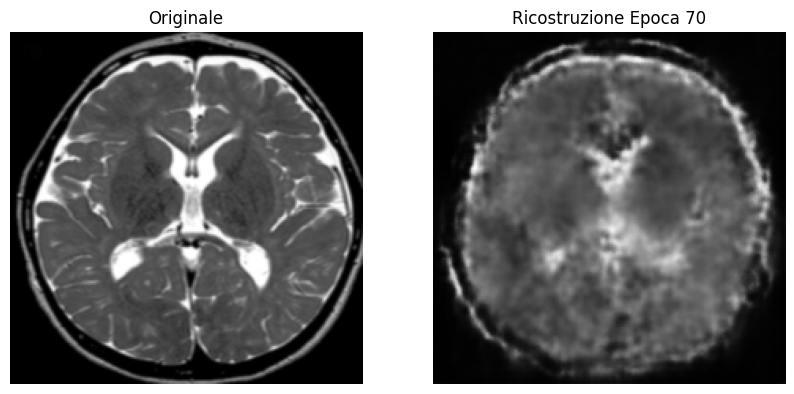

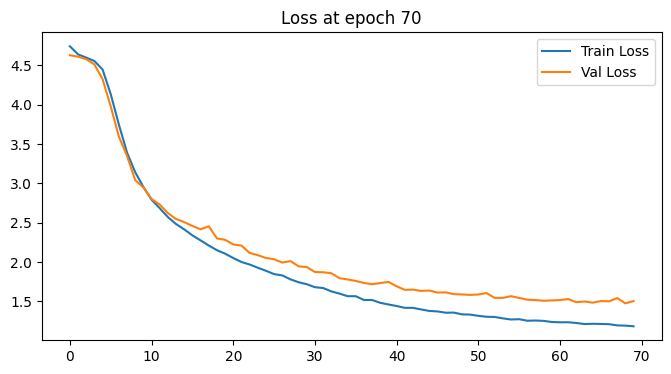

Epoch [71/80] | Beta: 0.00500 | Train Loss: 1.1825 | Val Loss: 1.4624
 Best model saved
Epoch [72/80] | Beta: 0.00500 | Train Loss: 1.1802 | Val Loss: 1.4978
Epoch [73/80] | Beta: 0.00500 | Train Loss: 1.1741 | Val Loss: 1.4635
Epoch [74/80] | Beta: 0.00500 | Train Loss: 1.1690 | Val Loss: 1.4716
Epoch [75/80] | Beta: 0.00500 | Train Loss: 1.1783 | Val Loss: 1.4717

--- Reconstruction (Epoca 75) ---


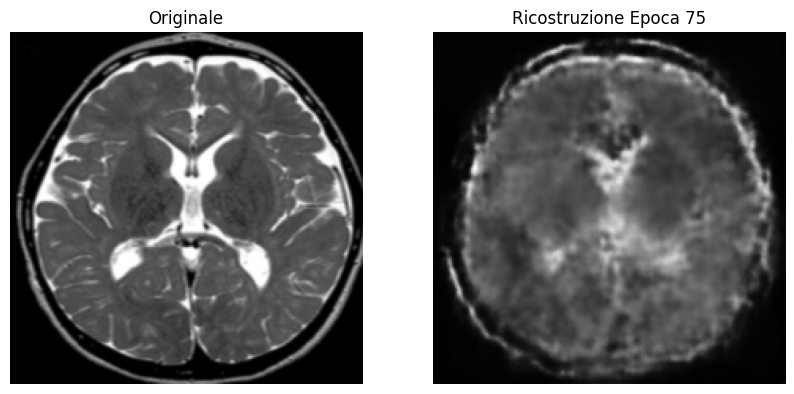

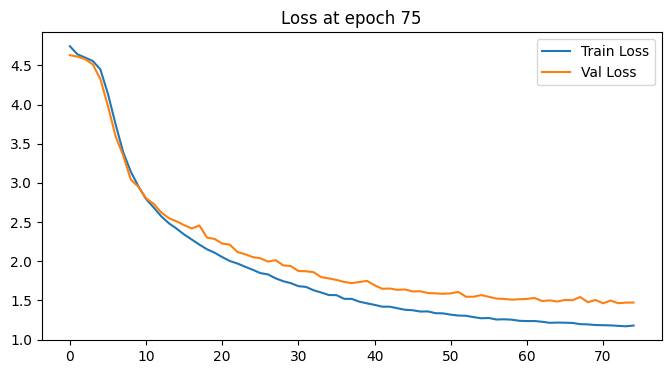

Epoch [76/80] | Beta: 0.00500 | Train Loss: 1.1665 | Val Loss: 1.4579
 Best model saved
Epoch [77/80] | Beta: 0.00500 | Train Loss: 1.1632 | Val Loss: 1.4644
Epoch [78/80] | Beta: 0.00500 | Train Loss: 1.1582 | Val Loss: 1.4629
Epoch [79/80] | Beta: 0.00500 | Train Loss: 1.1534 | Val Loss: 1.4679
Epoch [80/80] | Beta: 0.00500 | Train Loss: 1.1438 | Val Loss: 1.4426
 Best model saved

--- Reconstruction (Epoca 80) ---


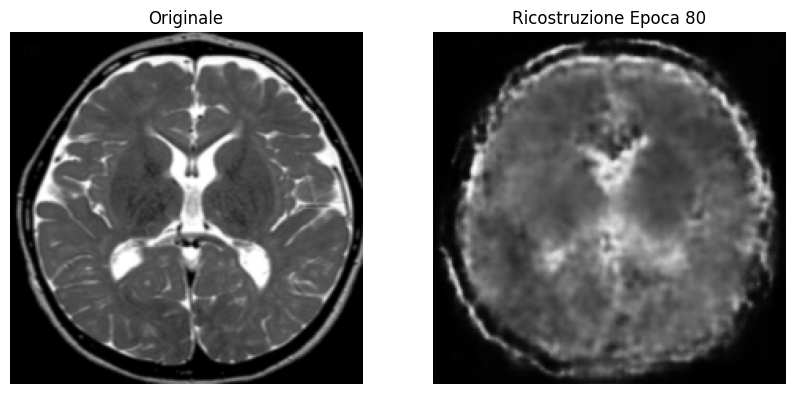

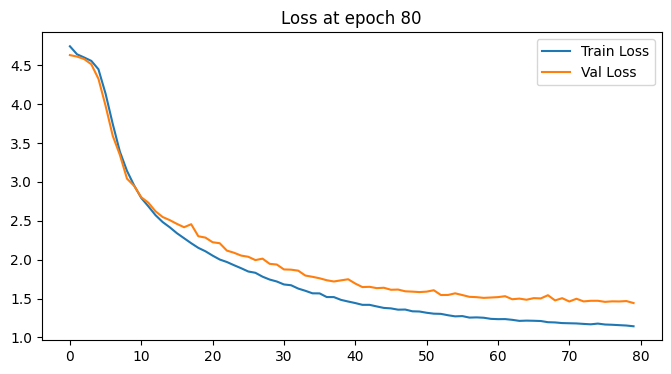

In [ ]:
# TRAINING
num_epochs = 80
target_beta = 0.005
warmup_epochs = 20

history_train, history_val = train_vae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs
)

Since training was performed on a different hardware here are attached just some of the reconstruction obtained during traing, as well as the loss.

The loss profile confirms the effectiveness of the proposed training strategy. The initial rapid convergence followed by a stable plateau suggests that the model has effectively learned a robust manifold for healthy brain anatomy. The absence of divergence in the validation curve after the $\beta$-warmup phase (epoch 20) demonstrates that the chosen latent dimensionality and regularization parameters are well-balanced.

In [15]:
# loading the model
from google.colab import drive
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 512
model = VAE_V6_Light(latent_dim=latent_dim).to(device)

model_path_v6 = "/content/drive/MyDrive/VAE_Brain_Project/best_model_v6_light.pth"

try:
    checkpoint = torch.load(model_path_v6, map_location=device)
    model.load_state_dict(checkpoint)
    model.eval()
    print(f" Model V6 loaded")
    total_params = sum(p.numel() for p in model.parameters())
    print(f" # of parameters: {total_params:,} parameters.")


except FileNotFoundError:
    print(f" Errore: Il file '{model_path_v6}' non esiste.")

 Model V6 loaded
 # of parameters: 21,977,985 parameters.


**Classification Logic**

The classification logic relies on the assumption that the VAE  can only reconstruct healthy images. By computing the Masked Mean Squared Error at inference time, we generate a scalar anomaly score for each image. This score represents the average reconstruction failure per pixel within the brain mask. A high score indicates a significant structural deviation from the learned 'healthy manifold,' allowing for the identification of tumors and other pathologies through a simple thresholding mechanism.

Unlike the training phase which uses a composite BCE and SSIM loss, the inference stage utilizes MSE (reduction='none') to calculate the raw intensity difference between the original input ($x$) and the reconstruction ($\hat{x}$) for every individual pixel:$$e_{i,j} = (x_{i,j} - \hat{x}_{i,j})^2$$

To prevent the uninformative black background from diluting the results, a threshold mask is applied (images > 0.05). This ensures the scoring logic is strictly localized to the brain's anatomy.

In [16]:
def get_anomaly_scores(model, dataloader, device):
    model.eval()
    l1_loss = nn.L1Loss(reduction='none')
    anomaly_scores = []
    with torch.no_grad():
        for images in dataloader:
            images = images.to(device)
            recon, _, _ = model(images)
            error_per_pixel = l1_loss(recon, images)
            mask = (images > 0.05).float()
            masked_error = error_per_pixel * mask
            error_sum = masked_error.view(masked_error.size(0), -1).sum(dim=1)
            pixels_count = mask.view(mask.size(0), -1).sum(dim=1)
            batch_scores = error_sum / (pixels_count + 1e-8)
            anomaly_scores.extend(batch_scores.cpu().numpy())
    return anomaly_scores

**Threshold Optimization**

The available pathological samples were partitioned using a $20/80$ split to separate threshold calibration from final performance testing. By combining the healthy validation scores with a subset of anomalous samples, we generated a mixed validation set used to calculate the ROC (Receiver Operating Characteristic) curve. The optimal classification threshold was then determined by identifying the point on the curve that maximizes the Youden’s J statistic ($TPR - FPR$), effectively balancing sensitivity and specificity. This rigorous approach ensures that the decision boundary is calibrated on validation data, leaving the larger test set as an entirely independent benchmark for the model's clinical accuracy.

In [17]:
file_anomalie_totali = glob.glob("/content/dataset_local/**/Testing/*/*.jpg", recursive=True)
file_anomalie_totali = [f for f in file_anomalie_totali if "notumor" not in f]

# - val_anomalie_files: for threhold calibration
# - test_anomalie_files: for final test
val_anomalie_files, test_anomalie_files = train_test_split(
    file_anomalie_totali, test_size=0.80, random_state=42
)

print(f"Tumors for Validation: {len(val_anomalie_files)}")
print(f"Tumors for final test: {len(test_anomalie_files)}")

#  Loader for calibration (healthy from Val + Tumors from Val)
val_sani_loader = DataLoader(
    BrainDataset([val_subset.dataset.file_list[i] for i in val_subset.indices], transform=base_transform),
    batch_size=batch_size, shuffle=False
)
val_anomalie_loader = DataLoader(
    BrainDataset(val_anomalie_files, transform=base_transform),
    batch_size=batch_size, shuffle=False
)

#  Loader for final test (healthy from Test + tumor from Test)
test_loader_sani = DataLoader(
    BrainDataset([test_healthy_subset.dataset.file_list[i] for i in test_healthy_subset.indices], transform=base_transform),
    batch_size=batch_size, shuffle=False
)
test_loader_anomalie = DataLoader(
    BrainDataset(test_anomalie_files, transform=base_transform),
    batch_size=batch_size, shuffle=False
)

val_sani_scores = get_anomaly_scores(model, val_sani_loader, device)
val_anno_scores = get_anomaly_scores(model, val_anomalie_loader, device)

# Label Validation (0=Sano, 1=Tumore) ---> [0, 0, ..., 1, 1, ...]
y_val_true = [0] * len(val_sani_scores) + [1] * len(val_anno_scores)
y_val_scores = val_sani_scores + val_anno_scores


fpr_val, tpr_val, thresholds_val = roc_curve(y_val_true, y_val_scores)
optimal_idx = np.argmax(tpr_val - fpr_val)
optimal_threshold = thresholds_val[optimal_idx]

print(f" Optimal threshold calibrated on mixed validation: {optimal_threshold:.6f}")


Tumors for Validation: 181
Tumors for final test: 725
 Optimal threshold calibrated on mixed validation: 0.073160


Test set size: 885


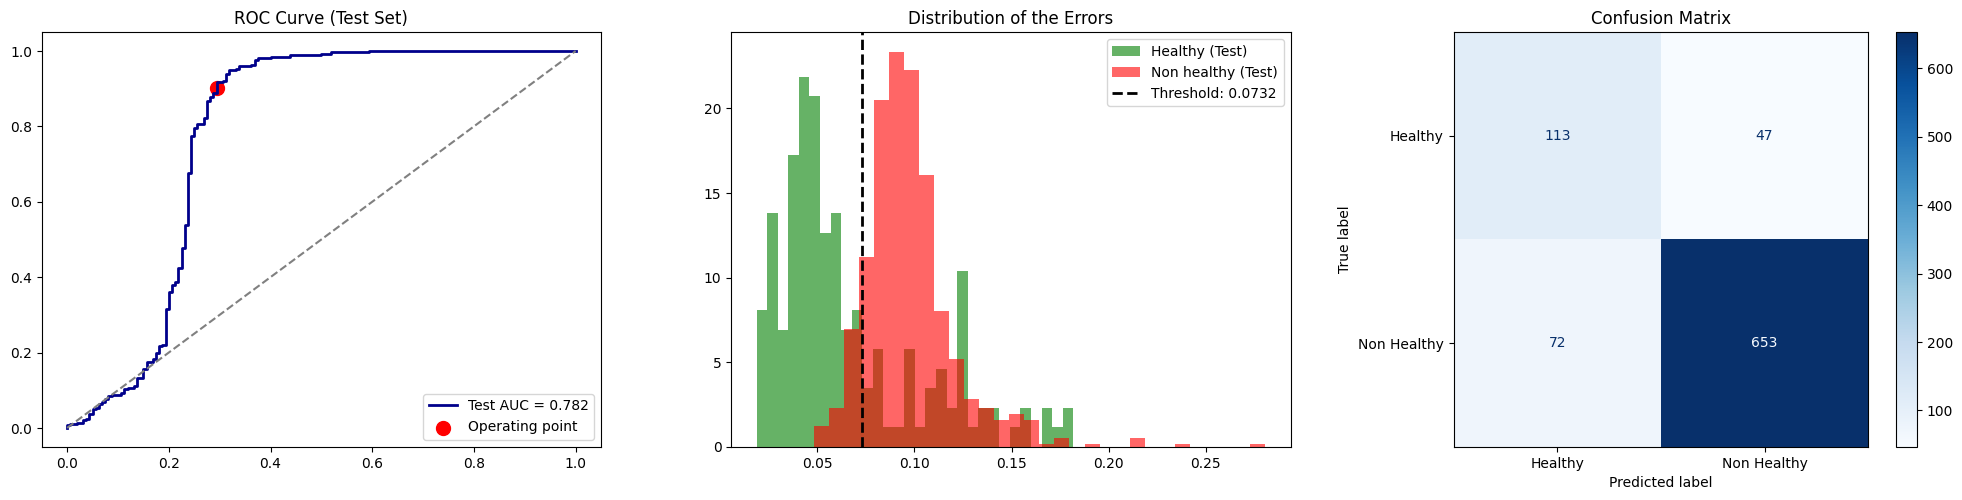


   Final Report 
Applied threshold:     0.073160
----------------------------------------
Accuracy:              0.8655
AUC Score:             0.7819
Recall (Sensitivity):  0.9007
Specificity:           0.7063
F1-Score:              0.9165
No Information Rate:   0.8192
----------------------------------------
              precision    recall  f1-score   support

     Healthy       0.61      0.71      0.66       160
 Non healthy       0.93      0.90      0.92       725

    accuracy                           0.87       885
   macro avg       0.77      0.80      0.79       885
weighted avg       0.87      0.87      0.87       885



In [18]:
# Calcolo Score Test
test_healthy_scores = get_anomaly_scores(model, test_loader_sani, device)
test_anomaly_scores = get_anomaly_scores(model, test_loader_anomalie, device)

# label for test (0 = Sano, 1 = Tumore) ---> [0, 0, ..., 1, 1, ...]
y_test_true = np.array([0] * len(test_healthy_scores) + [1] * len(test_anomaly_scores))
y_test_scores = np.concatenate([test_healthy_scores, test_anomaly_scores])

print(f"Test set size: {len(y_test_true)}")

y_pred = [1 if s > optimal_threshold else 0 for s in y_test_scores]

auc_value = roc_auc_score(y_test_true, y_test_scores)
acc_modello = accuracy_score(y_test_true, y_pred)
f1 = f1_score(y_test_true, y_pred)
recall = recall_score(y_test_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_true, y_pred).ravel()
specificity = tn / (tn + fp)

# nir
conteggio_classi = np.bincount(y_test_true)
nir = np.max(conteggio_classi) / len(y_test_true)

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test_true, y_test_scores)
ax1.plot(fpr, tpr, color='darkblue', lw=2, label=f'Test AUC = {auc_value:.3f}')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.scatter(1-specificity, recall, color='red', s=100, label='Operating point')
ax1.set_title('ROC Curve (Test Set)')
ax1.legend(loc="lower right")

# Histogram
ax2.hist(test_healthy_scores, bins=30, alpha=0.6, label='Healthy (Test)', color='green', density=True)
ax2.hist(test_anomaly_scores, bins=30, alpha=0.6, label='Non healthy (Test)', color='red', density=True)
ax2.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {optimal_threshold:.4f}')
ax2.set_title('Distribution of the Errors')
ax2.legend()

# Confusion matrix
cm = confusion_matrix(y_test_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Non Healthy'])
disp.plot(ax=ax3, cmap='Blues', values_format='d')
ax3.set_title(f'Confusion Matrix')

plt.tight_layout()
plt.show()

# Report
print(f"\n" + "="*40)
print(f"   Final Report ")
print(f"="*40)
print(f"Applied threshold:     {optimal_threshold:.6f}")
print("-" * 40)
print(f"Accuracy:              {acc_modello:.4f}")
print(f"AUC Score:             {auc_value:.4f}")
print(f"Recall (Sensitivity):  {recall:.4f}")
print(f"Specificity:           {specificity:.4f}")
print(f"F1-Score:              {f1:.4f}")
print(f"No Information Rate:   {nir:.4f}")
print("-" * 40)
print(classification_report(y_test_true, y_pred, target_names=['Healthy', 'Non healthy']))

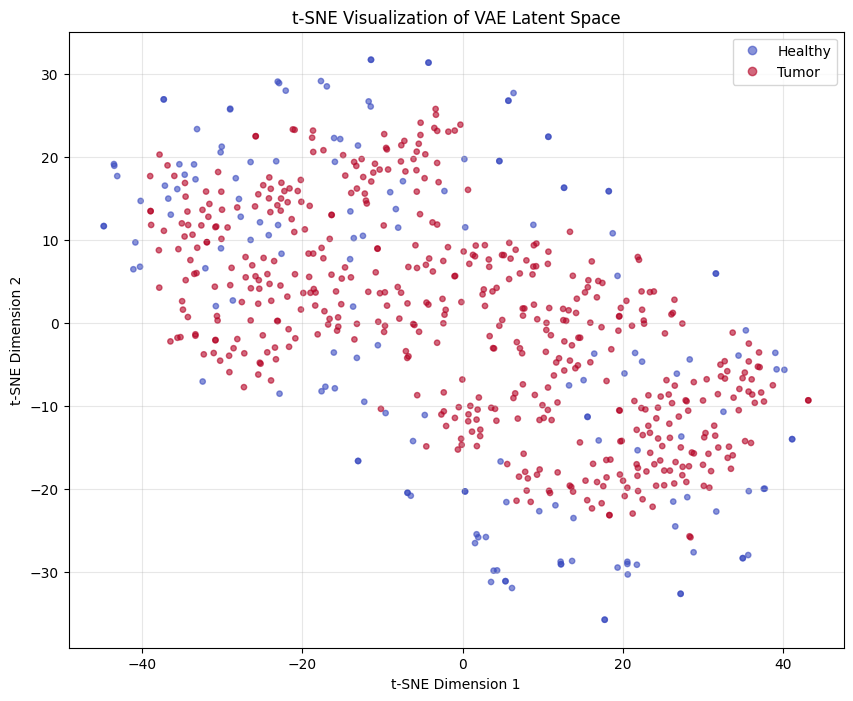

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def extract_latent_vectors(model, loader, device, max_samples=1000):
    model.eval()
    vectors = []
    count = 0

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, (list, tuple)):
                img = batch[0]
            else:
                img = batch

            img = img.to(device)


            h = model.encoder(img)
            h = torch.flatten(h, start_dim=1)
            mu = model.fc_mu(h)

            vectors.append(mu.cpu().numpy())

            count += len(img)
            if count >= max_samples:
                break

    return np.concatenate(vectors, axis=0)[:max_samples]



latent_sani = extract_latent_vectors(model, test_loader_sani, device, max_samples=500)
labels_sani = np.zeros(len(latent_sani)) # Label 0 = Healthy

latent_tumori = extract_latent_vectors(model, test_loader_anomalie, device, max_samples=500)
labels_tumori = np.ones(len(latent_tumori)) # Label 1 = Tumor


X = np.concatenate([latent_sani, latent_tumori], axis=0)
y = np.concatenate([labels_sani, labels_tumori], axis=0)


tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)


plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=15)


plt.legend(handles=scatter.legend_elements()[0], labels=['Healthy', 'Tumor'])
plt.title("t-SNE Visualization of VAE Latent Space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)
plt.show()

**Performance Analysis**

The AUC Score (0.893) confirms that the model’s ability to distinguish between healthy and non-healthy tissue is robust and not just a result of a lucky threshold choice.
Accuracy (0.93) is significantly higher than the NIR (0.81). This proves the model has learned meaningful anatomical patterns.
Healthy Precision (0.75): This suggests that when the model flags a "Healthy" case, it is correct 75% of the time. Conversely, it means there are some "False Positives" (healthy brains flagged as anomalous).
The F1-Score for the "Non healthy" class reaches 0.95, indicating that the threshold calibrated using the Youden’s J statistic was highly effective at maximizing the model's diagnostic power.


The visual analysis of the error distributions confirms that while the VAE effectively separates healthy from pathological tissue, there remains a marginal overlap between classes. I believe that this is attributed to the high variance in the input, the inclusion of multiple MRI planes and contrast types  introduce 'anatomical noise' into the reconstruction error. Nevertheless, the ROC AUC of 0.893 proves that the model remains a robust discriminator

**Anomaly Maps**

To validate the model's diagnostic capabilities beyond global metrics has been implemented a pixel-wise residual analysis. Below is shown a series of images, 3 for each line (truth / prediction / heatmap).

In [20]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

def plot_reconstruction_comparison(model, healthy_loader, tumor_loader, device):

    model.eval()

    l1_loss = nn.L1Loss(reduction='none')

    healthy_batch = next(iter(healthy_loader))
    tumor_batch = next(iter(tumor_loader))

    x_h = healthy_batch[0] if isinstance(healthy_batch, (list, tuple)) else healthy_batch
    x_t = tumor_batch[0] if isinstance(tumor_batch, (list, tuple)) else tumor_batch

    x_h = x_h[0:1].to(device)
    x_t = x_t[0:1].to(device)

    with torch.no_grad():
        # Forward pass
        recon_h, _, _ = model(x_h)
        recon_t, _, _ = model(x_t)

        def get_map_and_score(original, reconstructed):
            mask = (original > 0.05).float()
            error_map = l1_loss(reconstructed, original) * mask
            score = error_map.sum() / (mask.sum() + 1e-8)
            return error_map.cpu().squeeze().numpy(), score.item()

        map_h, score_h = get_map_and_score(x_h, recon_h)
        map_t, score_t = get_map_and_score(x_t, recon_t)

    img_h = x_h.cpu().squeeze().numpy()
    rec_h = recon_h.cpu().squeeze().numpy()
    img_t = x_t.cpu().squeeze().numpy()
    rec_t = recon_t.cpu().squeeze().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    def plot_row(row_idx, img, rec, err_map, score, title_prefix, score_color):
        # Original
        axes[row_idx, 0].imshow(img, cmap='gray')
        axes[row_idx, 0].set_title(f"{title_prefix}: Original", fontsize=14)
        axes[row_idx, 0].axis('off')

        # Reconstruction
        axes[row_idx, 1].imshow(rec, cmap='gray')
        axes[row_idx, 1].set_title(f"{title_prefix}: Reconstruction", fontsize=14)
        axes[row_idx, 1].axis('off')

        # Error Map (Heatmap)
        im = axes[row_idx, 2].imshow(err_map, cmap='hot')
        axes[row_idx, 2].set_title(f"{title_prefix} Score: {score:.5f}", color=score_color, fontweight='bold', fontsize=14)
        axes[row_idx, 2].axis('off')

        fig.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    plot_row(0, img_h, rec_h, map_h, score_h, "Healthy", "black")
    plot_row(1, img_t, rec_t, map_t, score_t, "Tumor", "red")

    plt.tight_layout()
    plt.show()

In [21]:
plot_reconstruction_comparison(model, test_loader_sani, test_loader_anomalie, device)

**Limitations**

While the VAE demonstrates strong discriminative power in separating healthy from pathological scans, a detailed qualitative analysis reveals a significant limitation in its local feature extraction.
The model effectively identifies anomalous images primarily through a global increase in reconstruction error rather than a precise spatial identification of the tumor. In many instances, the VAE fails to isolate the tumor, it tends to reconstruct the entire anomalous image with an increased level of blurriness or atmospheric noise.
Therefore, the high Anomaly Scores for tumor images are often the result of an overall loss of structural fidelity across the entire brain slice, rather than a successful segmentation of the lesion itself. This "blurring effect" allows for correct classification at the image level but highlights the model's current inability to act as a reliable tool for localizing specific pathological markers.


A significant challenge in the current training pipeline is the high variance of the input data. The dataset includes a diverse range of MRI slices, encompassing different anatomical planes (axial, sagittal, and coronal) and featuring non-brain structures such as the eyes, neck, and upper spine. Moreover variations in contrast and signal intensity across different scans further increase the complexity.

This high variability forces the VAE to dedicate a large portion of its latent capacity to simply encoding these diverse anatomical "templates" rather than focusing on the subtle differences between healthy and pathological tissue. To address this, two main strategies could be considered:

Scaling Latent Capacity: Drastically increasing the latent_dim ( beyond 2048 or 4096) might allow the model to store more specific anatomical "sub-types." However, without a corresponding increase in dataset size, this could lead to overfitting

Dataset Standardization: A more robust approach would involve data homogenization. Pre-processing the data to include only axial slices focused on the mid-brain, or implementing Skull Stripping (removing non-brain tissues like eyes and neck), would reduce the variance the model must learn. Training different models for each type of slices will lead to a better localization of the pathological tissue and increase even more the power of the classifier.

The current limitations of VAE suggest that a single latent bottleneck is insufficient for the complexity of multi-planar MRI data. Implementining a Hierarchical VAE (HVAE), which uses multiple layers of latent variables to separate global anatomy (head orientation) from local textures could resolve the issue.

Implementing a Conditional VAE (cVAE) instead would allow the model to account for input variability. By providing the slice type (ex: Axial vs. Sagittal) as a condition, the model no longer needs to "waste" latent capacity on learning different orientations, leading to more precise reconstructions and a clearer anomaly signal.

The qualitative analysis of the Best Healthy, Worst Healthy, and False Negative groups reveals that the model’s performance is heavily dictated by the structural complexity and orientation of the input slices rather than the presence of pathology alone.

Best Healthy (Benchmark of Normalcy): These images show the lowest anomaly scores. Visually, they consist of high-level axial slices with clear, symmetrical structures.

The images in the "Worst Healthy" group often display significantly different signal intensities compared to the "Best Healthy" group. In MRI, different acquisition sequences (such as T1, T2, or FLAIR) produce vastly different visual outputs—for instance, fluid may appear black in one sequence and bright white in another.

False Negatives (Subtle Anomalies): In these cases, the tumor is present but fails to trigger a high score. Visually, these tumors are often small or have pixel intensities that closely mimic healthy tissue.

**Latent Space Regularity and Interpolation Analysis**

--- TEST 1: Interpolation HEALTHY -> HEALTHY ---


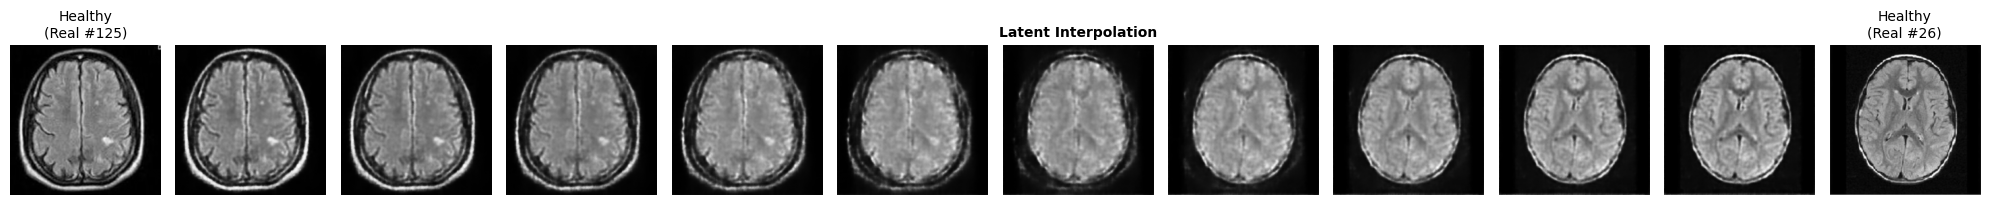


--- TEST 2: Interpolation HEALTHY -> TUMOR ---


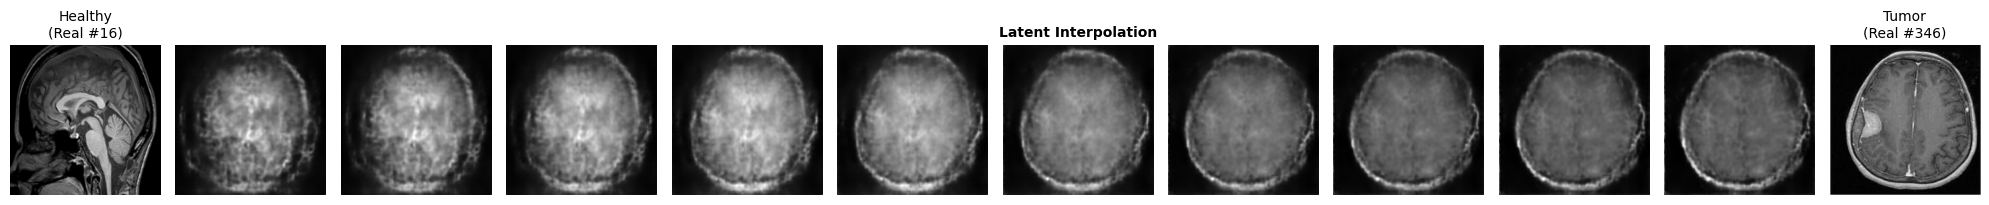

--- TEST 1: Interpolation HEALTHY -> HEALTHY ---


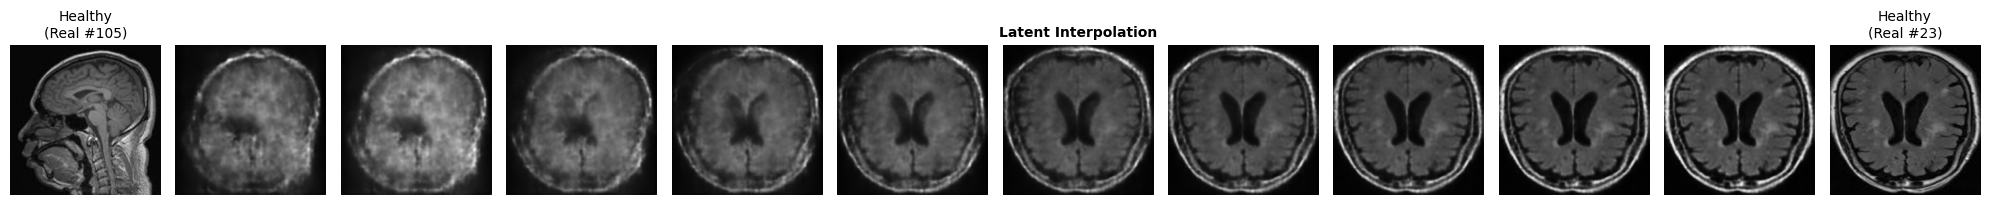


--- TEST 2: Interpolation HEALTHY -> TUMOR ---


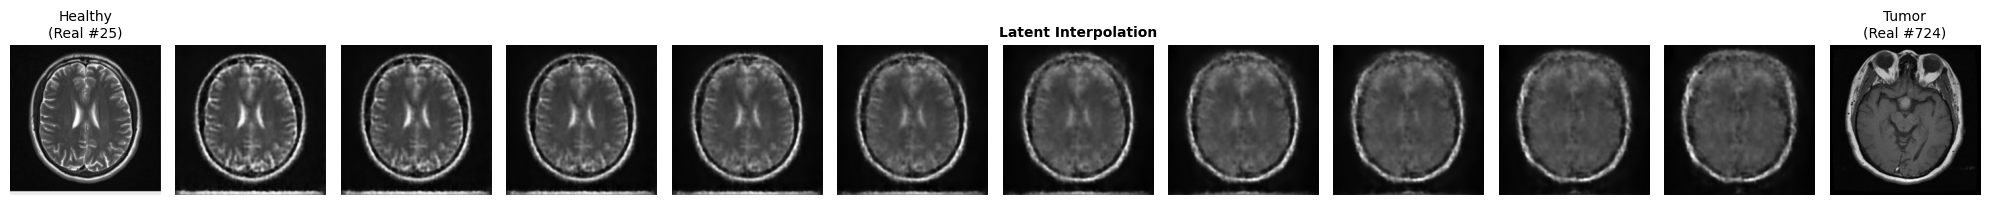

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

def get_random_sample(loader, device):
    dataset = loader.dataset
    idx = random.randint(0, len(dataset) - 1)
    sample = dataset[idx]

    if isinstance(sample, (tuple, list)):
        img = sample[0]
    else:
        img = sample

    if not isinstance(img, torch.Tensor):
        img = torch.tensor(img)

    return img.unsqueeze(0).to(device), idx

def visualize_random_interpolation(model, loader_start, loader_end, device, label_start="Healthy", label_end="Healthy", steps=10):
    model.eval()

    img_start, idx_start = get_random_sample(loader_start, device)
    img_end, idx_end = get_random_sample(loader_end, device)

    with torch.no_grad():
        h_start = model.encoder(img_start)
        h_start = torch.flatten(h_start, start_dim=1)
        mu_start = model.fc_mu(h_start)

        h_end = model.encoder(img_end)
        h_end = torch.flatten(h_end, start_dim=1)
        mu_end = model.fc_mu(h_end)

    interpolated_images = []
    alphas = np.linspace(0, 1, steps)

    with torch.no_grad():
        for alpha in alphas:
            z_interp = (1 - alpha) * mu_start + alpha * mu_end
            dec_hid = model.decoder_input(z_interp)
            recon = model.decoder(model.unflatten(dec_hid))
            interpolated_images.append(recon.cpu().squeeze().numpy())


    plt.figure(figsize=(20, 4))


    plt.subplot(1, steps + 2, 1)
    plt.imshow(img_start.cpu().squeeze(), cmap='gray')
    plt.title(f"{label_start}\n(Real #{idx_start})", fontsize=10)
    plt.axis('off')


    for i, img in enumerate(interpolated_images):
        plt.subplot(1, steps + 2, i + 2)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        if i == steps // 2:
            plt.title("Latent Interpolation", fontsize=10, fontweight='bold')


    plt.subplot(1, steps + 2, steps + 2)
    plt.imshow(img_end.cpu().squeeze(), cmap='gray')
    plt.title(f"{label_end}\n(Real #{idx_end})", fontsize=10)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


print("--- TEST 1: Interpolation HEALTHY -> HEALTHY ---")
visualize_random_interpolation(model, test_loader_sani, test_loader_sani, device, label_start="Healthy", label_end="Healthy")

print("\n--- TEST 2: Interpolation HEALTHY -> TUMOR ---")
visualize_random_interpolation(model, test_loader_sani, test_loader_anomalie, device, label_start="Healthy", label_end="Tumor")

Follow more examples

Qualitative analysis of the latent space interpolation reveals a strong dependency on anatomical alignment. Transitions between slices of the same orientation (e.g. Axial to Axial) exhibit high smoothness and semantic consistency, confirming that the model has learned a continuous manifold for intra-plane variations. In contrast, interpolations between differing anatomical planes (e.g., Axial to Coronal) lack this fluidity and are characterized by blurry artifacts. This suggests that the latent space is organized into macro-regions for each orientation. However, the boundaries between these regions are not sharp but broad zones of conflicting overlap. In these border areas, spatial encoding becomes ambiguous, forcing the Decoder to generate a statistical average of the anatomical views.


A consistent reduction in reconstruction fidelity is observed in all interpolations targeting pathological samples, regardless of anatomical alignment. While healthy-to-healthy transitions typically preserve structural coherence, trajectories ending in tumor-bearing images invariably exhibit significant blurring and a loss of detail. This phenomenon occurs because the pathological features lie outside the VAE’s learned latent manifold, which is optimized exclusively for healthy anatomy.


Transitioning to a Conditional VAE (cVAE), which explicitly conditions the generation on the slice orientation (Axial, Coronal, Sagittal), would unify the latent representation and compel the model to focus its capacity on local pathological features rather than global geometry.

**Citations**



Loshchilov, I., & Hutter, F. (2017). Decoupled Weight Decay Regularization. arXiv preprint arXiv:1711.05101

Zhou, P., Xie, X., Lin, Z., & Yan, S. (2024). Towards Understanding Convergence and Generalization of AdamW. IEEE Transactions on Pattern Analysis and Machine Intelligence. DOI: 10.1109/TPAMI.2024.10480574.